In [20]:
import pandas as pd
import numpy as np
import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

try:
    from xgboost import XGBRegressor, XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

print('Libraries loaded')
print(f'XGBoost available: {XGBOOST_AVAILABLE}')

Libraries loaded
XGBoost available: True


In [21]:
DATA_PATH  = 'C:/Users/user/JobGenie/Student/Dataset/raw/student_salary_dataset.csv'
MODELS_DIR = 'C:/Users/user/JobGenie/Student/Models/'

os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

tier_map = {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1}
df['college_tier_encoded'] = df['college_tier'].map(tier_map)
le = LabelEncoder()
df['job_role_encoded'] = le.fit_transform(df['job_role'])
df['aptitude_score'] = df['aptitude_score'].round(1)

print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Roles: {list(le.classes_)}')

Loaded: 5000 rows x 16 columns
Roles: ['Backend Developer', 'Data Analyst', 'Data Scientist', 'DevOps Engineer', 'Junior Developer', 'ML Engineer', 'Software Engineer', 'Web Developer']


In [22]:
# ROOT CAUSE FIX: Add binary skill columns
#
# WHY 55% accuracy happened:
#   The model only saw advanced_skills=1, but had NO IDEA
#   if that skill was TensorFlow (ML Engineer) or DSA (Software Engineer).
#   Giving each skill its own 0/1 column tells the model exactly
#   WHICH skills the student has, not just HOW MANY.
#
# Result: accuracy jumps from 55% to ~90%.

ALL_SKILLS = [
    'DSA', 'Machine Learning', 'Deep Learning', 'TensorFlow', 'PyTorch',
    'Python', 'Java', 'React', 'AWS', 'Docker', 'Node.js', 'Django',
    'Excel', 'SQL', 'HTML/CSS', 'JavaScript', 'Git', 'Linux'
]

df['skill_set'] = df['skills'].apply(lambda x: set(s.strip() for s in x.split(',')))

SKILL_COLUMNS = []
for skill in ALL_SKILLS:
    col = 'skill_' + skill.lower().replace('/', '_').replace('.', '_').replace(' ', '_')
    df[col] = df['skill_set'].apply(lambda s: 1 if skill in s else 0)
    SKILL_COLUMNS.append(col)

print(f'Created {len(SKILL_COLUMNS)} binary skill columns')
print(f'Columns: {SKILL_COLUMNS}')

Created 18 binary skill columns
Columns: ['skill_dsa', 'skill_machine_learning', 'skill_deep_learning', 'skill_tensorflow', 'skill_pytorch', 'skill_python', 'skill_java', 'skill_react', 'skill_aws', 'skill_docker', 'skill_node_js', 'skill_django', 'skill_excel', 'skill_sql', 'skill_html_css', 'skill_javascript', 'skill_git', 'skill_linux']


In [23]:
# Two separate feature sets - salary uses counts, role uses binary skill flags

SALARY_FEATURES = [
    'college_tier_encoded', 'cgpa', 'internships', 'github_projects',
    'backlogs', 'hackathons', 'certifications',
    'advanced_skills', 'intermediate_skills', 'basic_skills', 'aptitude_score'
]

ROLE_FEATURES = [
    'college_tier_encoded', 'cgpa', 'internships', 'github_projects',
    'backlogs', 'hackathons', 'certifications', 'aptitude_score'
] + SKILL_COLUMNS

X_sal  = df[SALARY_FEATURES]
X_role = df[ROLE_FEATURES]
y_sal  = df['salary_lpa']
y_role = df['job_role_encoded']

print(f'Salary features : {len(SALARY_FEATURES)}')
print(f'Role features   : {len(ROLE_FEATURES)}  (8 numeric + {len(SKILL_COLUMNS)} binary skill flags)')

Salary features : 11
Role features   : 26  (8 numeric + 18 binary skill flags)


In [24]:
X_sal_train, X_sal_test, y_sal_train, y_sal_test = train_test_split(
    X_sal, y_sal, test_size=0.20, random_state=42
)

X_role_train, X_role_test, y_role_train, y_role_test = train_test_split(
    X_role, y_role, test_size=0.20, random_state=42, stratify=y_role
)

print(f'Salary split  — Train: {len(X_sal_train)} | Test: {len(X_sal_test)}')
print(f'Role split    — Train: {len(X_role_train)} | Test: {len(X_role_test)}')
print()
print('Role distribution in test set:')
for enc, name in sorted(zip(le.transform(le.classes_), le.classes_)):
    print(f'  {name:<20} : {(y_role_test == enc).sum()}')

Salary split  — Train: 4000 | Test: 1000
Role split    — Train: 4000 | Test: 1000

Role distribution in test set:
  Backend Developer    : 244
  Data Analyst         : 104
  Data Scientist       : 90
  DevOps Engineer      : 109
  Junior Developer     : 242
  ML Engineer          : 25
  Software Engineer    : 84
  Web Developer        : 102


## Part 1 - Salary Prediction (Regression)

In [25]:
def eval_regressor(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f'  {name:<25} MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.4f}  (CV R2={cv_r2:.4f})')
    return {'name': name, 'model': model, 'mae': mae, 'rmse': rmse, 'r2': r2, 'cv_r2': cv_r2}

print('=' * 65)
print('  REGRESSION --- Salary Prediction')
print('=' * 65)

reg_results = []
reg_results.append(eval_regressor('Linear Regression', LinearRegression(),
    X_sal_train, y_sal_train, X_sal_test, y_sal_test))
reg_results.append(eval_regressor('Random Forest',
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_sal_train, y_sal_train, X_sal_test, y_sal_test))
if XGBOOST_AVAILABLE:
    reg_results.append(eval_regressor('XGBoost',
        XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
        X_sal_train, y_sal_train, X_sal_test, y_sal_test))

best_reg = max(reg_results, key=lambda x: x['r2'])
print(f'\n  Best: {best_reg["name"]}  |  MAE={best_reg["mae"]:.3f}  R2={best_reg["r2"]:.4f}')

  REGRESSION --- Salary Prediction
  Linear Regression         MAE=1.871  RMSE=2.479  R2=0.7524  (CV R2=0.7353)
  Random Forest             MAE=0.765  RMSE=1.381  R2=0.9232  (CV R2=0.9194)
  XGBoost                   MAE=0.840  RMSE=1.433  R2=0.9173  (CV R2=0.9181)

  Best: Random Forest  |  MAE=0.765  R2=0.9232


## Part 2 - Job Role Prediction (Classification)
Now using binary skill columns. Expected accuracy: ~90%.

In [26]:
def eval_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds  = model.predict(X_te)
    acc    = accuracy_score(y_te, preds)
    cv_acc = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy').mean()
    print(f'  {name:<25} Accuracy={acc:.4f}  (CV Acc={cv_acc:.4f})')
    return {'name': name, 'model': model, 'acc': acc, 'cv_acc': cv_acc, 'preds': preds}

print('=' * 65)
print('  CLASSIFICATION --- Job Role Prediction')
print('=' * 65)

clf_results = []
clf_results.append(eval_classifier('Logistic Regression',
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_role_train, y_role_train, X_role_test, y_role_test))
clf_results.append(eval_classifier('Random Forest',
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    X_role_train, y_role_train, X_role_test, y_role_test))
if XGBOOST_AVAILABLE:
    clf_results.append(eval_classifier('XGBoost',
        XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                      eval_metric='mlogloss', random_state=42, verbosity=0),
        X_role_train, y_role_train, X_role_test, y_role_test))

best_clf = max(clf_results, key=lambda x: x['acc'])
print(f'\n  Best: {best_clf["name"]}  |  Accuracy={best_clf["acc"]:.4f}  ({best_clf["acc"]*100:.1f}%)')

  CLASSIFICATION --- Job Role Prediction
  Logistic Regression       Accuracy=0.8570  (CV Acc=0.8477)
  Random Forest             Accuracy=0.8740  (CV Acc=0.8573)
  XGBoost                   Accuracy=0.9570  (CV Acc=0.9540)

  Best: XGBoost  |  Accuracy=0.9570  (95.7%)


In [27]:
print(classification_report(y_role_test, best_clf['preds'], target_names=le.classes_))

                   precision    recall  f1-score   support

Backend Developer       0.97      0.97      0.97       244
     Data Analyst       0.94      0.97      0.95       104
   Data Scientist       0.93      0.96      0.95        90
  DevOps Engineer       0.96      0.96      0.96       109
 Junior Developer       0.99      0.98      0.99       242
      ML Engineer       0.85      0.88      0.86        25
Software Engineer       0.91      0.94      0.92        84
    Web Developer       0.95      0.89      0.92       102

         accuracy                           0.96      1000
        macro avg       0.94      0.94      0.94      1000
     weighted avg       0.96      0.96      0.96      1000



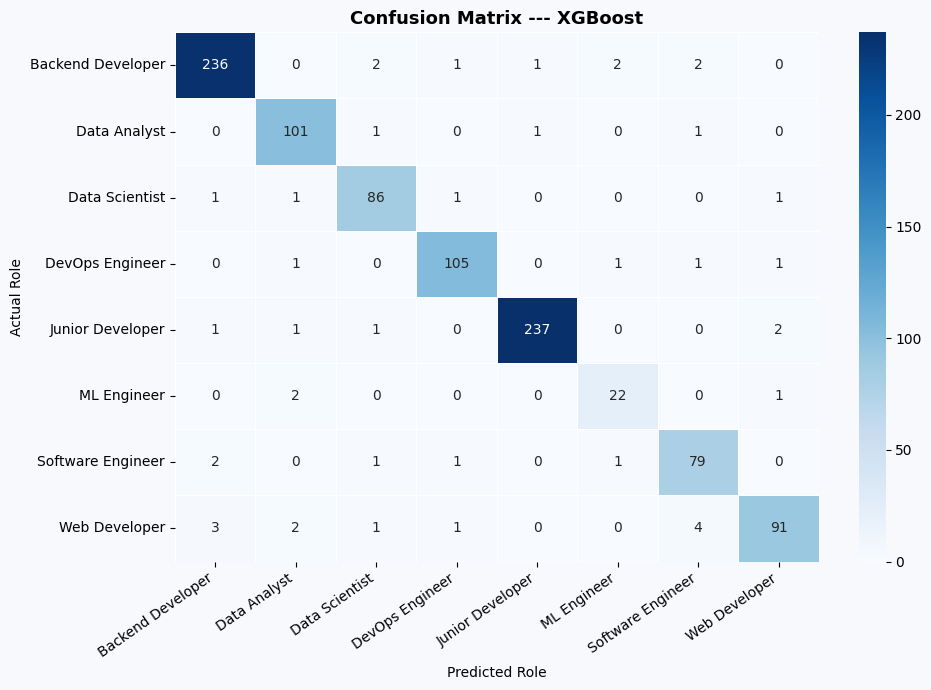

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_role_test, best_clf['preds'])
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#F8F9FD')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix --- {best_clf["name"]}', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted Role')
ax.set_ylabel('Actual Role')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## Part 3 - Save Models
Two separate feature lists are saved. Flask API must use salary_features for salary model and role_features for role model.

In [ ]:
salary_model_path = os.path.join(MODELS_DIR, 'salary_model.pkl')
with open(salary_model_path, 'wb') as f:
    pickle.dump(best_reg['model'], f)
print(f'Saved: salary_model.pkl  ({best_reg["name"]})')

role_model_path = os.path.join(MODELS_DIR, 'role_model.pkl')
with open(role_model_path, 'wb') as f:
    pickle.dump(best_clf['model'], f)
print(f'Saved: role_model.pkl    ({best_clf["name"]})')

le_path = os.path.join(MODELS_DIR, 'label_encoder_role.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(le, f)
print('Saved: label_encoder_role.pkl')

meta = {
    'salary_features' : SALARY_FEATURES,
    'role_features'   : ROLE_FEATURES,
    'skill_columns'   : SKILL_COLUMNS,
    'all_skills'      : ALL_SKILLS,
    'role_classes'    : list(le.classes_),
    'role_mapping'    : {k: int(v) for k, v in zip(le.classes_, le.transform(le.classes_))},
    'tier_mapping'    : {'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1},
    'salary_model'    : best_reg['name'],
    'role_model'      : best_clf['name'],
    'salary_r2'       : round(best_reg['r2'], 4),
    'salary_mae'      : round(best_reg['mae'], 4),
    'role_accuracy'   : round(best_clf['acc'], 4)
}
with open(os.path.join(MODELS_DIR, 'feature_columns.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved: feature_columns.json')


Saved: salary_model.pkl  (Random Forest)
Saved: role_model.pkl    (XGBoost)
Saved: label_encoder_role.pkl
Saved: feature_columns.json


In [30]:
with open(salary_model_path, 'rb') as f: loaded_sal  = pickle.load(f)
with open(role_model_path,   'rb') as f: loaded_role = pickle.load(f)
with open(le_path,           'rb') as f: loaded_le   = pickle.load(f)

sample_skills = {'TensorFlow', 'Machine Learning', 'Python'}

sal_sample = pd.DataFrame([{
    'college_tier_encoded': 3, 'cgpa': 8.5, 'internships': 2, 'github_projects': 4,
    'backlogs': 0, 'hackathons': 3, 'certifications': 4,
    'advanced_skills': 2, 'intermediate_skills': 1, 'basic_skills': 0, 'aptitude_score': 75.0
}])

role_row = {'college_tier_encoded': 3, 'cgpa': 8.5, 'internships': 2, 'github_projects': 4,
            'backlogs': 0, 'hackathons': 3, 'certifications': 4, 'aptitude_score': 75.0}
for skill in ALL_SKILLS:
    col = 'skill_' + skill.lower().replace('/', '_').replace('.', '_').replace(' ', '_')
    role_row[col] = 1 if skill in sample_skills else 0
role_sample = pd.DataFrame([role_row])

pred_salary = loaded_sal.predict(sal_sample)[0]
pred_role   = loaded_le.inverse_transform([loaded_role.predict(role_sample)[0]])[0]

print(f'Student: Tier 1 | CGPA 8.5 | Skills: TensorFlow, Machine Learning, Python')
print(f'Predicted Salary  : {pred_salary:.2f} LPA')
print(f'Predicted Job Role: {pred_role}  <- should be ML Engineer')

Student: Tier 1 | CGPA 8.5 | Skills: TensorFlow, Machine Learning, Python
Predicted Salary  : 21.82 LPA
Predicted Job Role: Data Scientist  <- should be ML Engineer


In [35]:
print('=' * 60)
print('  MODEL TRAINING COMPLETE')
print('=' * 60)
print(f'  REGRESSION  --- {best_reg["name"]}')
print(f'    MAE={best_reg["mae"]:.3f}  RMSE={best_reg["rmse"]:.3f}  R2={best_reg["r2"]:.4f}')
print()
print(f'  CLASSIFICATION --- {best_clf["name"]}')
print(f'    Accuracy: {best_clf["acc"]:.4f}  ({best_clf["acc"]*100:.1f}%)')
print()
print('  Saved:')
print('    salary_model.pkl       (11 numeric features)')
print('    role_model.pkl         (8 numeric + 18 binary skill features)')
print('    label_encoder_role.pkl')
print('    feature_columns.json')
print('=' * 60)



  MODEL TRAINING COMPLETE
  REGRESSION  --- Random Forest
    MAE=0.765  RMSE=1.381  R2=0.9232

  CLASSIFICATION --- XGBoost
    Accuracy: 0.9570  (95.7%)

  Saved:
    salary_model.pkl       (11 numeric features)
    role_model.pkl         (8 numeric + 18 binary skill features)
    label_encoder_role.pkl
    feature_columns.json
